In [2]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
Looking in indexes: https://mirrors.cloud.aliyuncs.com/pypi/simple
  Cloning https://gitee.com/hongwenzhang/pytorch3d.git to /tmp/pip-req-build-qmfbfvxy
  Running command git clone --filter=blob:none --quiet https://gitee.com/hongwenzhang/pytorch3d.git /tmp/pip-req-build-qmfbfvxy
  Resolved https://gitee.com/hongwenzhang/pytorch3d.git to commit b6a77ad7aaf41ed90fca80ce6a2bac3c462a7881
  Preparing metadata (pyproject.toml) ... done


迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: outputs/output_meshes/mesh_epoch_299.obj


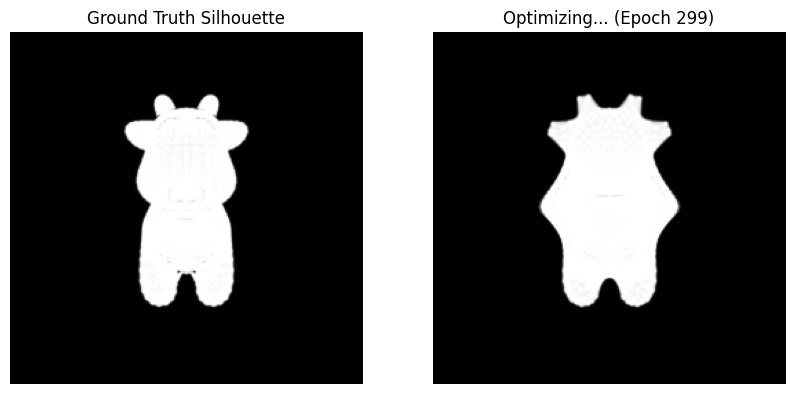

优化完成！所有中间状态的 .obj 文件已保存在 outputs/output_meshes 文件夹中。


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "data/cow.obj" 
if not os.path.exists(obj_path):
    raise FileNotFoundError("Missing data/cow.obj. Please keep the target model in the data directory.")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "outputs/output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

iter 0999/1000 | total=0.03235 | rgb=0.02020 | sil=0.00311 | edge=0.00395 | normal=0.02668 | lap=0.00482


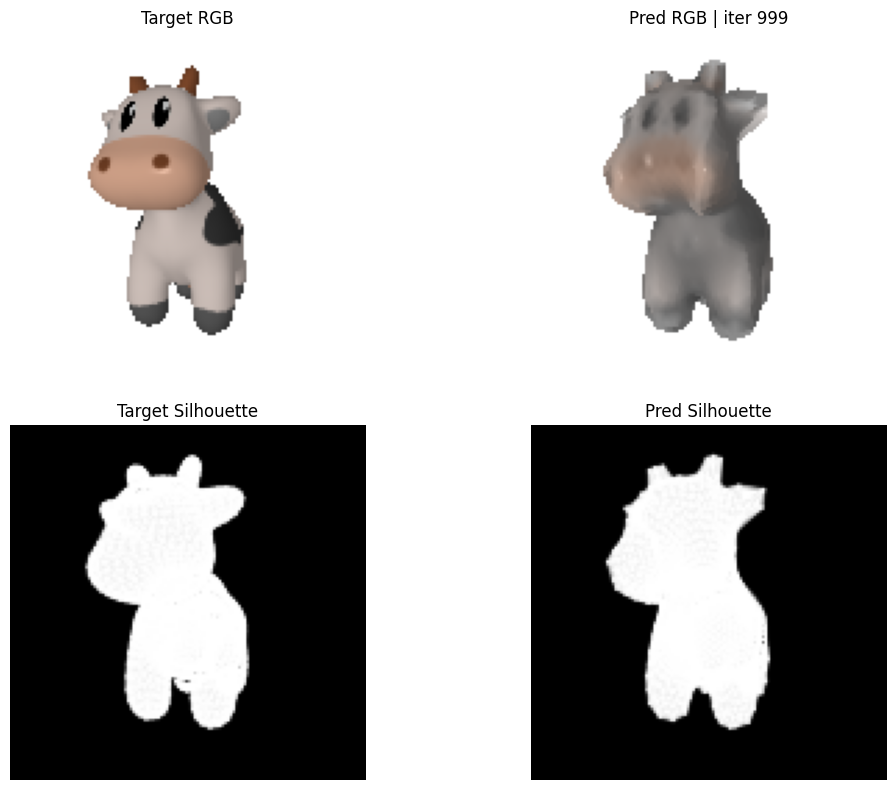

[*] 已保存带顶点颜色 OBJ: outputs/output_textured_meshes/colored_mesh_iter_0999.obj
[*] 已保存普通 OBJ: outputs/output_textured_meshes/mesh_iter_0999.obj
[*] 已生成优化过程 GIF: outputs/output_textured_meshes/texture_optimization.gif
选做联合纹理优化完成！
最终带顶点颜色模型: outputs/output_textured_meshes/final_colored_textured_fit.obj
最终普通模型: outputs/output_textured_meshes/final_plain_mesh.obj
过程 GIF: outputs/output_textured_meshes/texture_optimization.gif


In [9]:
# =========================================================
# 选做：联合纹理优化
# 参考 PyTorch3D 官方 fit_textured_mesh.ipynb
# 目标 cow 使用纹理：cow.obj + cow.mtl + cow_texture.png
# 源 mesh 从 ico_sphere 开始，同时优化形状 deform_verts 和顶点颜色 sphere_verts_rgb
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import clear_output

from pytorch3d.io import load_objs_as_meshes, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    TexturesVertex,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("当前运行设备:", device)


# ---------------------------------------------------------
# 1. 加载目标cow
# ---------------------------------------------------------
obj_filename = "data/cow.obj"

if not os.path.exists(obj_filename):
    raise FileNotFoundError("Missing data/cow.obj. Please keep the target model in the data directory.")

if not os.path.exists("data/cow.mtl"):
    raise FileNotFoundError("Missing data/cow.mtl. Please keep the material file in the data directory.")

if not os.path.exists("data/cow_texture.png"):
    raise FileNotFoundError("Missing data/cow_texture.png. Please keep the texture image in the data directory.")

target_mesh = load_objs_as_meshes([obj_filename], device=device)

verts = target_mesh.verts_packed()
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])
target_mesh.offset_verts_(-center)
target_mesh.scale_verts_(1.0 / float(scale))

if target_mesh.textures is None:
    raise ValueError(
        "cow.obj 没有成功加载纹理。请检查 cow.obj 中是否有 mtllib cow.mtl，"
        "cow.mtl 中是否有 map_Kd cow_texture.png。"
    )

print("目标 cow mesh 与真实纹理加载完成。")


# ---------------------------------------------------------
# 2. 多视角相机
# ---------------------------------------------------------
num_views = 20
image_size = 128

elev = torch.zeros(num_views, device=device)
azim = torch.linspace(-180, 180, num_views, device=device)

R, T = look_at_view_transform(
    dist=2.7,
    elev=elev,
    azim=azim,
)

cameras = FoVPerspectiveCameras(
    device=device,
    R=R,
    T=T,
)

target_cameras = [
    FoVPerspectiveCameras(
        device=device,
        R=R[i : i + 1],
        T=T[i : i + 1],
    )
    for i in range(num_views)
]

lights = PointLights(
    device=device,
    location=[[0.0, 0.0, -3.0]],
)


# ---------------------------------------------------------
# 3. 目标 RGB 渲染器：SoftPhongShader
# ---------------------------------------------------------
raster_settings_rgb = RasterizationSettings(
    image_size=image_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

renderer_rgb_target = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings_rgb,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=cameras,
        lights=lights,
    ),
)

target_batch = target_mesh.extend(num_views)

with torch.no_grad():
    target_images = renderer_rgb_target(
        target_batch,
        cameras=cameras,
        lights=lights,
    )
    target_rgb = [target_images[i, ..., :3].detach() for i in range(num_views)]

plt.figure(figsize=(12, 6))
for i in range(min(num_views, 10)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(target_rgb[i].cpu().numpy())
    plt.axis("off")
plt.suptitle("Target RGB Views")
plt.show()


# ---------------------------------------------------------
# 4. 目标剪影渲染器：SoftSilhouetteShader
# ---------------------------------------------------------
sigma = 1e-4

raster_settings_silhouette = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * sigma,
    faces_per_pixel=50,
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings_silhouette,
    ),
    shader=SoftSilhouetteShader(),
)

with torch.no_grad():
    silhouette_images = renderer_silhouette(
        target_batch,
        cameras=cameras,
        lights=lights,
    )
    target_silhouette = [silhouette_images[i, ..., 3].detach() for i in range(num_views)]

plt.figure(figsize=(12, 6))
for i in range(min(num_views, 10)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(target_silhouette[i].cpu().numpy(), cmap="gray")
    plt.axis("off")
plt.suptitle("Target Silhouette Views")
plt.show()


# ---------------------------------------------------------
# 5. 可微软 RGB 渲染器：用于优化阶段
# ---------------------------------------------------------
raster_settings_soft = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1.0 / 1e-4 - 1.0) * sigma,
    faces_per_pixel=50,
    perspective_correct=False,
)

renderer_textured = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings_soft,
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=cameras,
        lights=lights,
    ),
)


# ---------------------------------------------------------
# 6. 源模型：球体 + 可学习顶点颜色
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)

verts_shape = src_mesh.verts_packed().shape

deform_verts = torch.full(
    verts_shape,
    0.0,
    device=device,
    requires_grad=True,
)

sphere_verts_rgb = torch.full(
    [1, verts_shape[0], 3],
    0.5,
    device=device,
    requires_grad=True,
)

optimizer = torch.optim.SGD(
    [deform_verts, sphere_verts_rgb],
    lr=1.0,
    momentum=0.9,
)

output_dir = "outputs/output_textured_meshes"
os.makedirs(output_dir, exist_ok=True)

gif_frame_dir = os.path.join(output_dir, "gif_frames")
os.makedirs(gif_frame_dir, exist_ok=True)
gif_frames = []

print(f"输出目录: ./{output_dir}/")


# ---------------------------------------------------------
# 7. 损失函数与保存工具
# ---------------------------------------------------------
def update_mesh_shape_prior_losses(mesh, loss):
    loss["edge"] = mesh_edge_loss(mesh)
    loss["normal"] = mesh_normal_consistency(mesh)
    loss["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")


def build_current_mesh():
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    new_src_mesh.textures = TexturesVertex(
        verts_features=sphere_verts_rgb.clamp(0.0, 1.0)
    )
    return new_src_mesh


def save_vertex_color_obj(path, verts, faces, colors):
    with open(path, "w", encoding="utf-8") as f:
        for v, c in zip(verts.detach().cpu().tolist(), colors.detach().cpu().tolist()):
            f.write(
                f"v {v[0]:.8f} {v[1]:.8f} {v[2]:.8f} "
                f"{c[0]:.6f} {c[1]:.6f} {c[2]:.6f}\n"
            )
        for face in faces.detach().cpu().tolist():
            f.write(f"f {face[0] + 1} {face[1] + 1} {face[2] + 1}\n")


def visualize_prediction(pred_mesh, iteration, save_frame=True):
    with torch.no_grad():
        pred_img = renderer_textured(
            pred_mesh,
            cameras=target_cameras[1],
            lights=lights,
        )[0, ..., :3]

        pred_sil = renderer_silhouette(
            pred_mesh,
            cameras=target_cameras[1],
            lights=lights,
        )[0, ..., 3]

    fig = plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(target_rgb[1].cpu().numpy())
    plt.title("Target RGB")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(pred_img.detach().cpu().numpy())
    plt.title(f"Pred RGB | iter {iteration}")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.imshow(target_silhouette[1].cpu().numpy(), cmap="gray")
    plt.title("Target Silhouette")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.imshow(pred_sil.detach().cpu().numpy(), cmap="gray")
    plt.title("Pred Silhouette")
    plt.axis("off")

    plt.tight_layout()

    if save_frame:
        frame_path = os.path.join(gif_frame_dir, f"frame_{iteration:04d}.png")
        plt.savefig(frame_path, dpi=120)
        gif_frames.append(frame_path)

    plt.show()
    plt.close(fig)


# ---------------------------------------------------------
# 8. 联合优化循环
# ---------------------------------------------------------
num_views_per_iteration = 2
Niter = 1000
plot_period = 50

loss_weights = {
    "rgb": 1.0,
    "silhouette": 1.0,
    "edge": 1.0,
    "normal": 0.01,
    "laplacian": 1.0,
}

for i in range(Niter):
    optimizer.zero_grad()

    new_src_mesh = build_current_mesh()

    loss = {
        "rgb": torch.tensor(0.0, device=device),
        "silhouette": torch.tensor(0.0, device=device),
        "edge": torch.tensor(0.0, device=device),
        "normal": torch.tensor(0.0, device=device),
        "laplacian": torch.tensor(0.0, device=device),
    }

    update_mesh_shape_prior_losses(new_src_mesh, loss)

    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]

    for j in selected_views:
        images_predicted = renderer_textured(
            new_src_mesh,
            cameras=target_cameras[j],
            lights=lights,
        )

        predicted_rgb = images_predicted[..., :3]
        predicted_silhouette = images_predicted[..., 3]

        loss_rgb = ((predicted_rgb - target_rgb[j]) ** 2).mean()
        loss_silhouette = ((predicted_silhouette - target_silhouette[j]) ** 2).mean()

        loss["rgb"] += loss_rgb / num_views_per_iteration
        loss["silhouette"] += loss_silhouette / num_views_per_iteration

    sum_loss = torch.tensor(0.0, device=device)
    for k, v in loss.items():
        sum_loss = sum_loss + loss_weights[k] * v

    sum_loss.backward()
    optimizer.step()

    with torch.no_grad():
        sphere_verts_rgb.clamp_(0.0, 1.0)
        deform_verts.clamp_(-2.0, 2.0)

    if i % plot_period == 0 or i == Niter - 1:
        clear_output(wait=True)

        print(
            f"iter {i:04d}/{Niter} | "
            f"total={sum_loss.item():.5f} | "
            f"rgb={loss['rgb'].item():.5f} | "
            f"sil={loss['silhouette'].item():.5f} | "
            f"edge={loss['edge'].item():.5f} | "
            f"normal={loss['normal'].item():.5f} | "
            f"lap={loss['laplacian'].item():.5f}"
        )

        visualize_prediction(new_src_mesh, i, save_frame=True)

        current_verts, current_faces = new_src_mesh.get_mesh_verts_faces(0)
        current_colors = sphere_verts_rgb.detach().clamp(0.0, 1.0)[0]

        color_obj_path = os.path.join(output_dir, f"colored_mesh_iter_{i:04d}.obj")
        save_vertex_color_obj(
            color_obj_path,
            current_verts,
            current_faces,
            current_colors,
        )

        plain_obj_path = os.path.join(output_dir, f"mesh_iter_{i:04d}.obj")
        save_obj(
            plain_obj_path,
            current_verts,
            current_faces,
        )

        print(f"[*] 已保存带顶点颜色 OBJ: {color_obj_path}")
        print(f"[*] 已保存普通 OBJ: {plain_obj_path}")


# ---------------------------------------------------------
# 9. 生成优化过程 GIF
# ---------------------------------------------------------
gif_path = os.path.join(output_dir, "texture_optimization.gif")

if len(gif_frames) > 0:
    frames = [Image.open(p).convert("RGB") for p in gif_frames]
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=300,
        loop=0,
    )
    print(f"[*] 已生成优化过程 GIF: {gif_path}")
else:
    print("[!] 没有可用于生成 GIF 的帧。")


# ---------------------------------------------------------
# 10. 保存最终模型
# ---------------------------------------------------------
final_mesh = build_current_mesh()
final_verts, final_faces = final_mesh.get_mesh_verts_faces(0)
final_colors = sphere_verts_rgb.detach().clamp(0.0, 1.0)[0]

final_color_obj = os.path.join(output_dir, "final_colored_textured_fit.obj")
save_vertex_color_obj(
    final_color_obj,
    final_verts,
    final_faces,
    final_colors,
)

final_plain_obj = os.path.join(output_dir, "final_plain_mesh.obj")
save_obj(
    final_plain_obj,
    final_verts,
    final_faces,
)

print("选做联合纹理优化完成！")
print("最终带顶点颜色模型:", final_color_obj)
print("最终普通模型:", final_plain_obj)
print("过程 GIF:", gif_path)
